# Vibration Classification (Arduino Nano 33 BLE IMU) — Training

Goal:
- Load IMU CSV data (aX,aY,aZ,gX,gY,gZ)
- Build windows (100 samples) with overlap
- Train a compact, accurate model (1D CNN)
- Export to TensorFlow Lite (INT8) for Arduino

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Code (Paths + Class mapping)

In [6]:
from pathlib import Path

# Notebook is inside: 2-Training/Notebooks/
BASE_DIR = Path.cwd().resolve()

DATASET_DIR = (BASE_DIR / ".." / "dataset").resolve()


FEATURES = ["aX","aY","aZ","gX","gY","gZ"]

CLASS_FILES = {
    "idle":   "vibration_idle.csv",
    "weak":   "weak.csv",
    "strong": "strong.csv",
}

label_to_id = {name: i for i, name in enumerate(CLASS_FILES.keys())}
id_to_label = {v: k for k, v in label_to_id.items()}
num_classes = len(label_to_id)

print("Notebook dir:", BASE_DIR)
print("Dataset dir :", DATASET_DIR, "| exists:", DATASET_DIR.exists())
print("Classes     :", label_to_id)



# Check dataset files exist
missing = []
for cname, fname in CLASS_FILES.items():
    p = DATASET_DIR / fname
    if not p.exists():
        missing.append(str(p))

if missing:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing))

print("All dataset files found ✅")

Notebook dir: C:\Users\noor\Desktop\Projet_Tiny_ML\Partie1\2-Training\Notebooks
Dataset dir : C:\Users\noor\Desktop\Projet_Tiny_ML\Partie1\2-Training\dataset | exists: True
Classes     : {'idle': 0, 'weak': 1, 'strong': 2}
All dataset files found ✅


Load CSV files

In [8]:
import pandas as pd
import numpy as np

# IMU feature columns expected in the CSV files
FEATURES = ["aX","aY","aZ","gX","gY","gZ"]

def load_csv_as_array(csv_path):
    """
    Load a CSV file containing IMU data.

    Parameters
    ----------
    csv_path : Path
        Path to the CSV file.

    Returns
    -------
    np.ndarray
        Array of shape (N, 6) containing the IMU signals.
    """

    # Read the CSV file
    df = pd.read_csv(csv_path)

    # Keep only the IMU columns and remove missing values
    df = df[FEATURES].dropna()

    # Convert to NumPy array (float32 for ML efficiency)
    return df.values.astype(np.float32)


# Dictionary that will store the raw signals for each class
raw_by_class = {}

# Load each class dataset
for cname, fname in CLASS_FILES.items():

    path = DATASET_DIR / fname

    raw_by_class[cname] = load_csv_as_array(path)

    print(cname, raw_by_class[cname].shape)

idle (4388, 6)
weak (4414, 6)
strong (4366, 6)


Inspect the loaded data

In [9]:
for cname, data in raw_by_class.items():

    print("Class:", cname)
    print("Shape:", data.shape)

    # Display the first rows of the dataset
    print("First samples:")
    print(data[:5])

    print()



Class: idle
Shape: (4388, 6)
First samples:
[[-0.191  0.023  0.953 -0.427  1.038 -0.061]
 [-0.188  0.026  0.954 -0.916  1.221  0.183]
 [-0.158  0.029  0.954 -0.549  1.648 -0.183]
 [-0.184  0.024  0.951 -0.793  1.77   0.366]
 [-0.183  0.021  0.953 -1.465  1.892 -0.366]]

Class: weak
Shape: (4414, 6)
First samples:
[[-0.132 -0.045  0.967  1.282  1.16   1.892]
 [-0.087 -0.003  0.961  0.732  1.587  1.587]
 [-0.042  0.005  0.96   0.977  1.953  1.038]
 [-0.07  -0.033  0.967  0.977  1.709  1.953]
 [-0.066 -0.025  0.965  1.282  1.404  1.404]]

Class: strong
Shape: (4366, 6)
First samples:
[[-3.210e-01 -9.510e-01 -2.000e-03  3.845e+00  3.235e+00  4.272e+00]
 [-3.090e-01 -9.610e-01  1.300e-02  1.709e+00  3.479e+00  4.822e+00]
 [-2.980e-01 -9.710e-01  6.000e-03 -6.100e-02  3.296e+00  3.601e+00]
 [-2.800e-01 -9.500e-01  7.000e-03 -2.136e+00  5.005e+00  2.747e+00]
 [-3.310e-01 -9.580e-01  2.200e-02  2.625e+00  5.981e+00  3.235e+00]]



Visualize the IMU signals

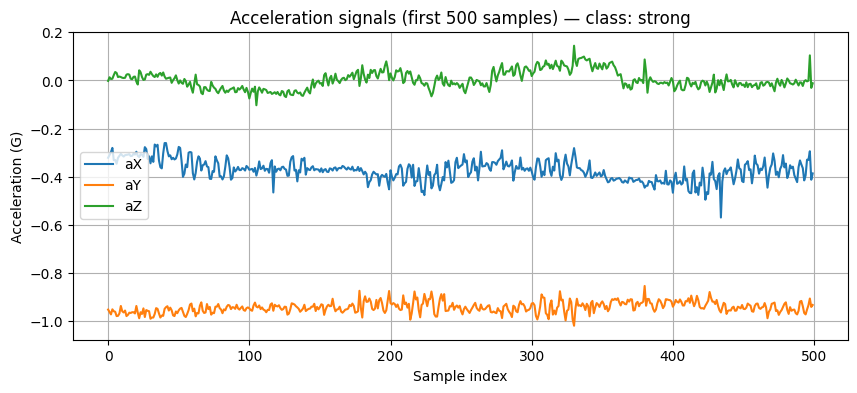

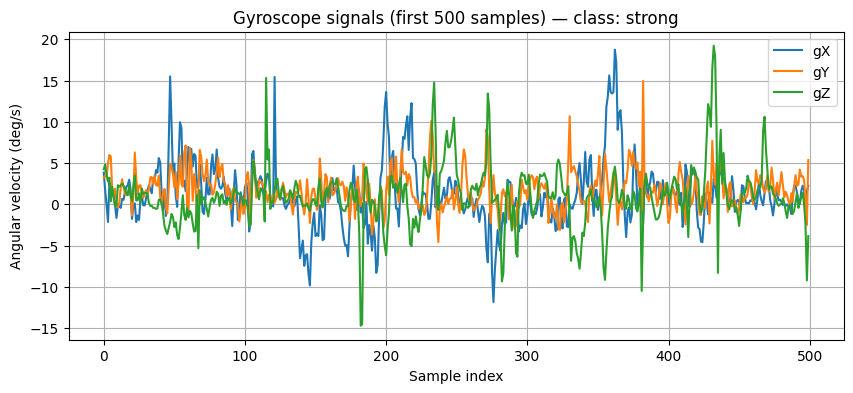

In [10]:
import matplotlib.pyplot as plt

# Select the class we want to visualize
example_class = "strong"

# Retrieve the corresponding IMU data
data = raw_by_class[example_class]


# ---------------------------------------------------------
# ACCELERATION SIGNALS (aX, aY, aZ)
# ---------------------------------------------------------

plt.figure(figsize=(10,4))

plt.plot(data[:500,0], label="aX")
plt.plot(data[:500,1], label="aY")
plt.plot(data[:500,2], label="aZ")

plt.title("Acceleration signals (first 500 samples) — class: strong")
plt.xlabel("Sample index")
plt.ylabel("Acceleration (G)")

plt.legend()
plt.grid()

plt.show()


# ---------------------------------------------------------
# GYROSCOPE SIGNALS (gX, gY, gZ)
# ---------------------------------------------------------

plt.figure(figsize=(10,4))

plt.plot(data[:500,3], label="gX")
plt.plot(data[:500,4], label="gY")
plt.plot(data[:500,5], label="gZ")

plt.title("Gyroscope signals (first 500 samples) — class: strong")
plt.xlabel("Sample index")
plt.ylabel("Angular velocity (deg/s)")

plt.legend()
plt.grid()

plt.show()

Compare acceleration of all classes

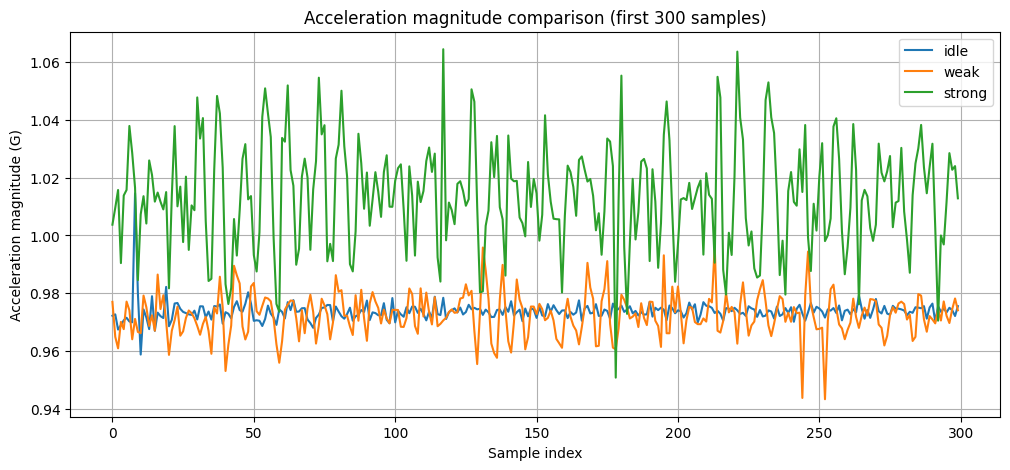

In [11]:
import matplotlib.pyplot as plt

# Number of samples to visualize
N = 300

plt.figure(figsize=(12,5))

for cname, data in raw_by_class.items():
    
    # Plot acceleration magnitude for comparison
    acc_mag = (data[:N,0]**2 + data[:N,1]**2 + data[:N,2]**2)**0.5
    
    plt.plot(acc_mag, label=cname)

plt.title("Acceleration magnitude comparison (first 300 samples)")
plt.xlabel("Sample index")
plt.ylabel("Acceleration magnitude (G)")
plt.legend()
plt.grid()

plt.show()

Compare gyroscope of all classes

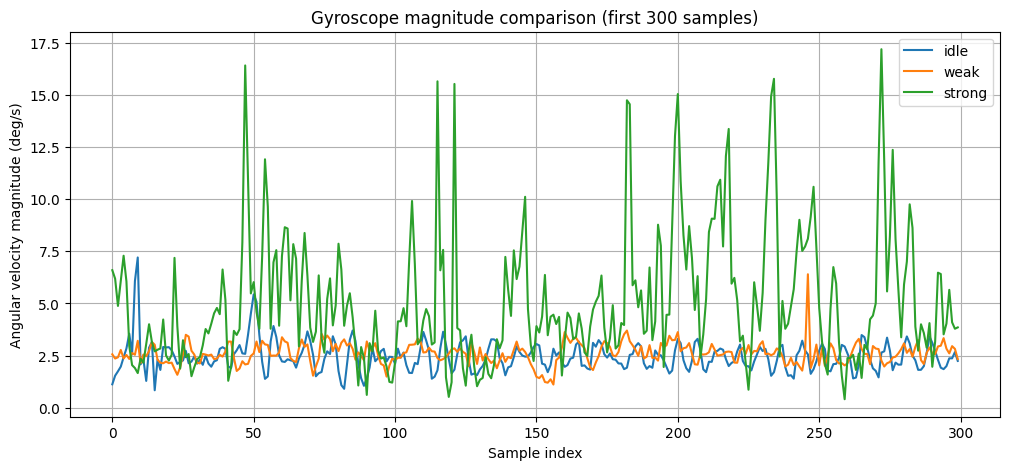

In [12]:
plt.figure(figsize=(12,5))

for cname, data in raw_by_class.items():
    
    # Gyroscope magnitude
    gyro_mag = (data[:N,3]**2 + data[:N,4]**2 + data[:N,5]**2)**0.5
    
    plt.plot(gyro_mag, label=cname)

plt.title("Gyroscope magnitude comparison (first 300 samples)")
plt.xlabel("Sample index")
plt.ylabel("Angular velocity magnitude (deg/s)")
plt.legend()
plt.grid()

plt.show()

Set window parameters

In [13]:
WINDOW_SIZE = 100   # samples per window
STRIDE = 20         # overlap step (smaller = more windows)
import numpy as np

def create_windows(data, window_size, stride):
    """
    Convert a continuous IMU signal into fixed-size windows.

    Parameters
    ----------
    data : np.ndarray
        Shape (N, 6) continuous IMU samples
    window_size : int
        Number of samples per window (e.g., 100)
    stride : int
        Step between consecutive windows (e.g., 20)

    Returns
    -------
    np.ndarray
        Shape (num_windows, window_size, 6)
    """
    windows = []
    N = data.shape[0]

    for start in range(0, N - window_size + 1, stride):
        windows.append(data[start:start + window_size])

    return np.stack(windows, axis=0) if windows else np.zeros((0, window_size, data.shape[1]), dtype=np.float32)

Build ML dataset (X, y)

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path

print(f"TensorFlow version = {tf.__version__}\n")

# ============================================
# REPRODUCIBILITY
# ============================================
# Fix random seeds to get the same results across runs
SEED = 1400
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================
# PROJECT PATHS (your folder structure)
# Notebook is in: 2-Training/Notebooks/
# Dataset is in : 2-Training/dataset/
# ============================================
NOTEBOOK_DIR = Path.cwd().resolve()
DATASET_DIR = (NOTEBOOK_DIR / ".." / "dataset").resolve()

print("Notebook dir:", NOTEBOOK_DIR)
print("Dataset dir :", DATASET_DIR, "\n")

# ============================================
# VIBRATION CLASSES (CSV filenames)
# ============================================
# Each class must have a corresponding CSV file in ../dataset/
VIBRATIONS = [
    "vibration_idle",   # -> vibration_idle.csv
    "weak",             # -> weak.csv
    "strong"            # -> strong.csv
]

# Number of samples per recording/window (100 samples = ~2 seconds @ 50 Hz)
SAMPLES_PER_VIBRATION = 100

NUM_VIBRATIONS = len(VIBRATIONS)

# ============================================
# ONE-HOT ENCODING
# ============================================
# Build one-hot vectors for labels:
# vibration_idle -> [1, 0, 0]
# weak          -> [0, 1, 0]
# strong        -> [0, 0, 1]
ONE_HOT_ENCODED_VIBRATIONS = np.eye(NUM_VIBRATIONS)

print("One-hot encoding:")
for i, vibration in enumerate(VIBRATIONS):
    print(f"  {vibration}: {ONE_HOT_ENCODED_VIBRATIONS[i]}")

# ============================================
# DATA EXTRACTION / PREPARATION
# ============================================
inputs = []   # feature vectors (6 values per recording)
outputs = []  # one-hot labels (3 values for 3 classes)

# Loop over each class file
for vibration_index in range(NUM_VIBRATIONS):
    vibration = VIBRATIONS[vibration_index]
    print(f"\n Processing class index {vibration_index} -> '{vibration}'...")

    # One-hot label for this class
    output = ONE_HOT_ENCODED_VIBRATIONS[vibration_index]

    # Load CSV
    csv_path = DATASET_DIR / f"{vibration}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)

    # Drop empty lines (NaNs) and re-index
    df = df.dropna().reset_index(drop=True)

    # How many full recordings of 100 samples do we have?
    num_recordings = int(df.shape[0] / SAMPLES_PER_VIBRATION)
    print(f"   ✓ Found {num_recordings} recording(s) in '{vibration}.csv'")

    # For each recording (block of 100 samples)
    for i in range(num_recordings):

        sum_a = 0.0
        sum_a2 = 0.0
        sum_g = 0.0
        sum_g2 = 0.0

        # Read 100 samples
        for j in range(SAMPLES_PER_VIBRATION):
            index = i * SAMPLES_PER_VIBRATION + j

            # Acceleration magnitude
            a_mag = np.sqrt(
                df['aX'][index]**2 +
                df['aY'][index]**2 +
                df['aZ'][index]**2
            )

            # Gyroscope magnitude
            g_mag = np.sqrt(
                df['gX'][index]**2 +
                df['gY'][index]**2 +
                df['gZ'][index]**2
            )

            # Accumulate for statistics
            sum_a += a_mag
            sum_a2 += a_mag**2
            sum_g += g_mag
            sum_g2 += g_mag**2

        # Compute statistical features for the block (100 samples)
        mean_a = sum_a / SAMPLES_PER_VIBRATION
        var_a  = sum_a2 / SAMPLES_PER_VIBRATION - mean_a**2
        rms_a  = np.sqrt(sum_a2 / SAMPLES_PER_VIBRATION)
        ene_a  = sum_a2

        mean_g = sum_g / SAMPLES_PER_VIBRATION
        var_g  = sum_g2 / SAMPLES_PER_VIBRATION - mean_g**2
        rms_g  = np.sqrt(sum_g2 / SAMPLES_PER_VIBRATION)
        ene_g  = sum_g2

        # Final feature vector (6 values)
        features = [
            rms_a, var_a, ene_a,
            rms_g, var_g, ene_g
        ]

        inputs.append(features)
        outputs.append(output)

# Convert lists to NumPy arrays (required by TensorFlow)
inputs = np.array(inputs, dtype=np.float32)   # shape: (N, 6)
outputs = np.array(outputs, dtype=np.float32) # shape: (N, 3)

print(f"\n✅ Data extraction completed!")
print(f"   - Total recordings: {len(inputs)}")
print(f"   - Inputs shape: {inputs.shape}")
print(f"   - Output shape: {outputs.shape}")
print(f"   - Features per input: {inputs.shape[1]}")
print(f"   - Number of classes: {NUM_VIBRATIONS}")

TensorFlow version = 2.20.0

Notebook dir: C:\Users\noor\Desktop\Projet_Tiny_ML\Partie1\2-Training\Notebooks
Dataset dir : C:\Users\noor\Desktop\Projet_Tiny_ML\Partie1\2-Training\dataset 

One-hot encoding:
  vibration_idle: [1. 0. 0.]
  weak: [0. 1. 0.]
  strong: [0. 0. 1.]

 Processing class index 0 -> 'vibration_idle'...
   ✓ Found 43 recording(s) in 'vibration_idle.csv'

 Processing class index 1 -> 'weak'...
   ✓ Found 44 recording(s) in 'weak.csv'

 Processing class index 2 -> 'strong'...
   ✓ Found 43 recording(s) in 'strong.csv'

✅ Data extraction completed!
   - Total recordings: 130
   - Inputs shape: (130, 6)
   - Output shape: (130, 3)
   - Features per input: 6
   - Number of classes: 3


In [16]:
import numpy as np
from pathlib import Path

# ============================================
# SHUFFLE THE DATASET
# ============================================
# Create a random permutation of indices so that the dataset is mixed.
# This helps to avoid class ordering effects (e.g., all idle samples first).
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

inputs = inputs[randomize]
outputs = outputs[randomize]

print("✅ Dataset shuffled!")
print("Total samples:", num_inputs)

# ============================================
# SPLIT INTO TRAIN / VALIDATION / TEST
# ============================================
# 60% train, 20% validation, 20% test
TRAIN_SPLIT = int(0.6 * num_inputs)  # 60%
VAL_SPLIT = int(0.2 * num_inputs) + TRAIN_SPLIT  # 60% + 20% = 80%

# np.split uses the indices as cut points
inputs_train, inputs_val, inputs_test = np.split(inputs, [TRAIN_SPLIT, VAL_SPLIT])
outputs_train, outputs_val, outputs_test = np.split(outputs, [TRAIN_SPLIT, VAL_SPLIT])

print("\n📊 Split summary:")
print(f"   - Train      : {len(inputs_train)} samples ({len(inputs_train)/num_inputs*100:.1f}%)")
print(f"   - Validation : {len(inputs_val)} samples ({len(inputs_val)/num_inputs*100:.1f}%)")
print(f"   - Test       : {len(inputs_test)} samples ({len(inputs_test)/num_inputs*100:.1f}%)")

# ============================================
# NORMALIZATION (TRAIN ONLY)
# ============================================
# Compute mean/std from training set only, then apply to all sets.
mean = np.mean(inputs_train, axis=0)
std = np.std(inputs_train, axis=0) + 1e-6  # small epsilon to avoid division by zero

inputs_train = (inputs_train - mean) / std
inputs_val   = (inputs_val   - mean) / std
inputs_test  = (inputs_test  - mean) / std

print("\n✅ Normalization done!")
print("Mean:", mean)
print("Std :", std)

# ============================================
# SAVE NORMALIZATION PARAMETERS
# ============================================
# Save mean/std so we can reuse them later (e.g., Arduino inference)
NOTEBOOK_DIR = Path.cwd().resolve()
MODELS_DIR = (NOTEBOOK_DIR / ".." / "models").resolve()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

np.save(MODELS_DIR / "mean.npy", mean)
np.save(MODELS_DIR / "std.npy", std)

print("\n✅ Saved mean/std in:", MODELS_DIR)
print(" - mean.npy")
print(" - std.npy")

# Quick shape check
print("\nShapes:")
print("inputs_train:", inputs_train.shape, "outputs_train:", outputs_train.shape)
print("inputs_val  :", inputs_val.shape,   "outputs_val  :", outputs_val.shape)
print("inputs_test :", inputs_test.shape,  "outputs_test :", outputs_test.shape)

✅ Dataset shuffled!
Total samples: 130

📊 Split summary:
   - Train      : 78 samples (60.0%)
   - Validation : 26 samples (20.0%)
   - Test       : 26 samples (20.0%)

✅ Normalization done!
Mean: [9.8614591e-01 2.0554654e-04 9.7283218e+01 3.9442329e+00 6.1837521e+00
 2.0385940e+03]
Std : [1.8657649e-02 2.7554404e-04 3.7062142e+00 2.1974897e+00 2.0333469e+01
 3.3605508e+03]

✅ Saved mean/std in: C:\Users\noor\Desktop\Projet_Tiny_ML\Partie1\2-Training\models
 - mean.npy
 - std.npy

Shapes:
inputs_train: (78, 6) outputs_train: (78, 3)
inputs_val  : (26, 6) outputs_val  : (26, 3)
inputs_test : (26, 6) outputs_test : (26, 3)


Training

In [ ]:


model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),   # 6 input features
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 output classes
])


# COMPILE MODEL

# Adam optimizer + categorical crossentropy
# because labels are one-hot encoded

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)




# ============================================
# TRAIN THE MODEL
# ============================================

print("\nStarting training...\n")

history = model.fit(
    inputs_train,
    outputs_train,
    epochs=90,            # number of passes over the dataset
    batch_size=8,          # samples processed before updating weights
    validation_data=(inputs_val, outputs_val),
    verbose=1
)

print("\n Training finished!")

📐 Model architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 20)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 383 (1.50 KB)

 Trainable params: 383 (1.50 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training...

Epoch 1/90
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1282 - loss: 1.1681 - val_accuracy: 0.2692 - val_loss: 1.1065
Epoch 2/90
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3974 - loss: 1.0544 - val_accuracy: 0.3846 - val_loss: 1.0218
Epoch 3/90
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.9706 - val_accuracy: 0.6154 - val_loss: 0.9439
Epoch 4/90
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6154 - loss: 0.9015 - val_accuracy: 0.6154 - val_loss: 0.8730
Epoch 5/90
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6154 - loss: 0.8418 - val_accuracy: 0.6538 - val_loss: 0.8088
Epoch 6/90
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6282 - loss: 0.7863 - val_accuracy: 0.6538 - val_loss: 0.7511
Epoch 7/90
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6410 - loss: 0.7388 - val_accuracy: 0.6538 - val_loss: 0.7018
Epoch 8/90
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6410 - loss: 0.6981 - val_ac

TRAINING CURVES

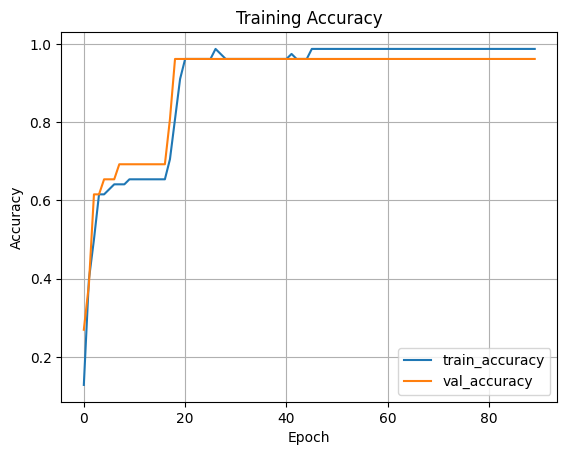

In [22]:
# ============================================
# TRAINING CURVES
# ============================================

import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.title("Training Accuracy")

plt.show()

Final Test 

In [23]:
test_loss, test_acc = model.evaluate(inputs_test, outputs_test)

print("\nTest accuracy:", test_acc)
print("Test loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0942

Test accuracy: 1.0
Test loss: 0.09418998658657074


Confusion matrix

Convert Keras model → TensorFlow Lite

Cette cellule va :

In [24]:
# ============================================
# CONVERT MODEL TO TENSORFLOW LITE
# ============================================

from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
MODELS_DIR = (NOTEBOOK_DIR / ".." / "models").resolve()

tflite_path = MODELS_DIR / "vibration_model.tflite"

# Create converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Apply default optimizations (smaller model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert
tflite_model = converter.convert()

# Save model
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model saved!")
print("Path:", tflite_path)
print("Model size:", len(tflite_model), "bytes")

INFO:tensorflow:Assets written to: C:\Users\noor\AppData\Local\Temp\tmpy1fa3bzm\assets


INFO:tensorflow:Assets written to: C:\Users\noor\AppData\Local\Temp\tmpy1fa3bzm\assets


Saved artifact at 'C:\Users\noor\AppData\Local\Temp\tmpy1fa3bzm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  3218581832720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3218581836176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3218586226896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3218586227088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3218586225744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3218586227472: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ TFLite model saved!
Path: C:\Users\noor\Desktop\Projet_Tiny_ML\Partie1\2-Training\models\vibration_model.tflite
Model size: 3652 bytes


In [25]:
from pathlib import Path

# ============================================
# PATHS (your project structure)
# ============================================
NOTEBOOK_DIR = Path.cwd().resolve()                       # 2-Training/Notebooks
TRAINING_DIR = (NOTEBOOK_DIR / "..").resolve()            # 2-Training
TFLITE_PATH  = (TRAINING_DIR / "models" / "vibration_model.tflite").resolve()

INFERENCE_DIR = (TRAINING_DIR / ".." / "3-Inference_Arduino").resolve()
INFERENCE_DIR.mkdir(parents=True, exist_ok=True)

HEADER_PATH = (INFERENCE_DIR / "model_data.h").resolve()

print("TFLite model:", TFLITE_PATH)
print("Header out :", HEADER_PATH)

if not TFLITE_PATH.exists():
    raise FileNotFoundError(f"Missing .tflite file: {TFLITE_PATH}")

# ============================================
# READ TFLITE BYTES
# ============================================
model_bytes = TFLITE_PATH.read_bytes()

# ============================================
# WRITE ARDUINO HEADER
# ============================================
with open(HEADER_PATH, "w", encoding="utf-8") as f:
    f.write("// Auto-generated file: TensorFlow Lite model as a C array\n")
    f.write("// Source: 2-Training/models/vibration_model.tflite\n\n")
    f.write("#pragma once\n")
    f.write("#include <cstdint>\n\n")

    f.write(f"const unsigned int g_model_len = {len(model_bytes)};\n")
    f.write("const unsigned char g_model[] = {\n  ")

    # Write bytes in hex format (12 bytes per line)
    for i, b in enumerate(model_bytes):
        f.write(f"0x{b:02x}, ")
        if (i + 1) % 12 == 0:
            f.write("\n  ")

    f.write("\n};\n")

print("\n✅ model_data.h generated successfully!")
print("Bytes:", len(model_bytes))

TFLite model: C:\Users\noor\Desktop\Projet_Tiny_ML\Partie1\2-Training\models\vibration_model.tflite
Header out : C:\Users\noor\Desktop\Projet_Tiny_ML\Partie1\3-Inference_Arduino\model_data.h

✅ model_data.h generated successfully!
Bytes: 3652
